# **0. Importar librerias**

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
from scipy import stats

# **1. CARGA Y EXPLORACIÓN INICIAL**

In [98]:
main_folder = Path.cwd().parent

data_folder = os.path.join(main_folder, 'data')


df, df_ip = [ pd.read_csv(os.path.join(data_folder, file)) for file in os.listdir(data_folder)]


In [99]:
df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,732758368.80,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,350311387.87,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2621473820.11,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3840542443.91,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,415583117.45,0


In [100]:
df_ip.head()

,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.00,16777471,Australia
1,16777472.00,16777727,China
2,16777728.00,16778239,China
3,16778240.00,16779263,Australia
4,16779264.00,16781311,China


## 1.1 Revisión de columnas y tipo de datos

In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


### 💾 **Observaciones**


Existe un total de **11 columnas** y **151112 registros**.
    - 10 son variables independientes
    - 1 variable dependiente (`class`)

Existen 2 columnas que parecen estar relacionadas con fechas pero están como str: `signup_time`, `purchase_time`.

Hay 5 columnas **numéricas** (`user_id`, `purchase_value`, `user_id`, `age`,`ip_address` y `class`), las 6 restantes son **str**.


No existen datos nulos aparentes.





In [102]:
df_ip.info()

<class 'pandas.DataFrame'>
RangeIndex: 138846 entries, 0 to 138845
Data columns (total 3 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   lower_bound_ip_address  138846 non-null  float64
 1   upper_bound_ip_address  138846 non-null  int64  
 2   country                 138846 non-null  str    
dtypes: float64(1), int64(1), str(1)
memory usage: 3.2 MB


### 💾 **Observaciones**


Existe un total de 3 columnas y 138846.

- 2 son numéricas relacionadas con limites de ip
- 1 de estas es str relacionada con el país de donde se efectuo la compra.



📢 **Conclusión**

Según lo señalado se debe revisar las columnas para ver si es necesario transformar alguna columna. En cuanto a las features relacionadas con tiempo deben ser cambiadas a su tipo correcto.

Revisar si es que en realidad no hay nulos como datos mal inputados, categorias faltantes u otros errores también debe estar presente en el análisis.

**Columnas a corregir**
- signup_time y purchase_time son object --> convertir a datetime
- source, browser, sex son object --> convertir a category (reducir memoria)


## 1.2 Revisión numérica somera

In [103]:
# No ver notación cientifica
pd.set_option('display.float_format', '{:.2f}'.format)

df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
user_id,151112.00,200171.04,115369.29,2.00,100642.50,199958.00,300054.00,400000.00
purchase_value,151112.00,36.94,18.32,9.00,22.00,35.00,49.00,154.00
age,151112.00,33.14,8.62,18.00,27.00,33.00,39.00,76.00
ip_address,151112.00,2152145330.96,1248497030.10,52093.50,1085933882.53,2154770162.41,3243257679.72,4294850499.68
class,151112.00,0.09,0.29,0.00,0.00,0.00,0.00,1.00


In [104]:
df_ip.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
lower_bound_ip_address,138846.00,2724531562.52,897521519.71,16777216.00,1919930368.00,3230887296.00,3350465280.00,3758096128.00
upper_bound_ip_address,138846.00,2724557062.22,897497915.46,16777471.00,1920008191.00,3230887551.00,3350465919.00,3758096383.00


### 💾 **Observaciones**

`purchase_value`: 
- **promedio**: 36.94 $
- **std**: 18.32 $
- **min**: 9 $
- **max**: 400000.00 $

`age`:

- **promedio**: 33 años
- **std**: 8.62 años
- **min**: 18 años
- **max**: 76 años



`lower_bound_ip_address`:

- **min**: 16777216
- **max**: 3758096128


`upper_bound_ip_address`:

- **min**: 16777471
- **max**: 3758096383

📢 **Conclusión**

El 75 % de los datos esta por debajo de los 49 $ de `purchase_value`. Considerando esto y el valor del maximo es interesante ver cuantos datos están fuera del 75 % y que tan altos son.

  - El std es bastante alto lo que debe ser principalmente por los valores ya nombrados.

La edad promedio de los clientes es de  33 años.
  - La edad mínima es 18 en sintonia con el negocio y la máxima de 76.
  - El std es alto pero no desmezutado como el de la columna anterior


En cuanto IP, podremos ver algo mas relacionandolo con el país.


`df` y `df_ip` se relacionan entre las ip. Con el ip de `df` hay que encontrar dentro de que rango cae y se le puede asignar un país a esa ip.

##  1.4. Unir los dataframes

In [105]:
df_ordenado = df.sort_values('ip_address')
df_ip_ordenado = df_ip.sort_values('lower_bound_ip_address')

df_merged = pd.merge_asof(
    df_ordenado,
    df_ip_ordenado,
    left_on='ip_address',
    right_on='lower_bound_ip_address',
    direction='backward'
)

In [106]:
df_merged.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,country
0,62421,2015-02-16 00:17:05,2015-03-08 10:00:39,46,ZCLZTAJPCRAQX,Direct,Safari,M,36,52093.50,0,NaN,NaN,NaN
1,173212,2015-03-08 04:03:22,2015-03-20 17:23:45,33,YFGYOALADBHLT,Ads,IE,F,30,93447.14,0,NaN,NaN,NaN
2,242286,2015-05-17 16:45:54,2015-05-26 08:54:34,33,QZNVQTUITFTHH,Direct,FireFox,F,32,105818.50,0,NaN,NaN,NaN
3,370003,2015-03-03 19:58:39,2015-05-28 21:09:13,33,PIBUQMBIELMMG,Ads,IE,M,40,117566.66,0,NaN,NaN,NaN
4,119824,2015-03-20 00:31:27,2015-04-05 07:31:46,55,WFIIFCPIOGMHT,Ads,Safari,M,38,131423.79,0,NaN,NaN,NaN


**Detalle**

Uso merge_assoft porque me permite hacer un merge utilizando rangos.
La idea es ordenar ambos dataset por la columna donde quiera comparar los rangos.

Utilizo `ip_address` en la tabla izquierda y `lower_bound_ip_address` en la derecha
para buscar el valor más cercano o igual hacia atrás de cada IP.

Aun así, esto dejará casos donde `ip_address` > `upper_bound_ip_address`.
En esos casos el país se marca como 'Unknown' ya que la IP no pertenece a ese rango.


##  1.5. Duplicados o nulos?

In [107]:
df_merged.isnull().sum()

user_id                     0
signup_time                 0
purchase_time               0
purchase_value              0
device_id                   0
source                      0
browser                     0
sex                         0
age                         0
ip_address                  0
class                       0
lower_bound_ip_address    634
upper_bound_ip_address    634
country                   634
dtype: int64

In [108]:
df_merged.duplicated().sum()

np.int64(0)

📢 Existen 634 valores nulos en el dataframe después de aplicar el merge. No existen duplicados

# **2. EDA**

## **2.1. Variables Numéricas**

In [109]:

tipo_de_datos = set([df_merged[col].dtype for col in df_merged.columns])

print(f'Los tipos de datos presentes en el dataframe son :{tipo_de_datos}')

Los tipos de datos presentes en el dataframe son :{<StringDtype(storage='python', na_value=nan)>, dtype('float64'), dtype('int64')}


In [110]:
numeric_df = df_merged.select_dtypes(include=['int', 'float'])
numeric_df

,user_id,purchase_value,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address
0,62421,46,36,52093.50,0,NaN,NaN
1,173212,33,30,93447.14,0,NaN,NaN
2,242286,33,32,105818.50,0,NaN,NaN
3,370003,33,40,117566.66,0,NaN,NaN
4,119824,55,38,131423.79,0,NaN,NaN
...,...,...,...,...,...,...,...
151107,361167,39,36,4294673680.77,0,3758096128.00,3758096383.00
151108,62422,62,22,4294714854.85,0,3758096128.00,3758096383.00
151109,260255,17,19,4294719533.35,0,3758096128.00,3758096383.00
151110,172984,9,35,4294822241.88,0,3758096128.00,3758096383.00


## 2.1.1 Target (Variable independiente)

In [111]:
numeric_df['class'].value_counts(normalize=True).rename(index={0: 'Legítimo (0)', 1: 'Fraudulento (1)'})*100

class
Legítimo (0)      90.64
Fraudulento (1)    9.36
Name: proportion, dtype: float64

C:\Users\remoto\AppData\Local\Temp\ipykernel_13384\2676706119.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(["Legítima", "Fraudulenta"])


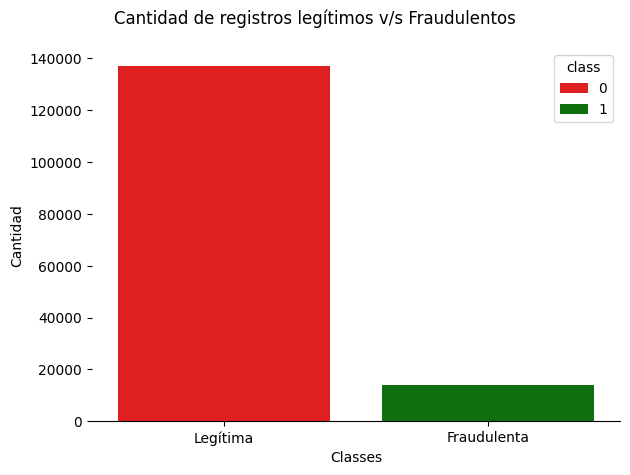

In [112]:
g = sns.countplot(data=numeric_df, x='class', hue='class', palette={0:'r', 1:'g'})
plt.suptitle('Cantidad de registros legítimos v/s Fraudulentos')
plt.xlabel('Classes')
plt.ylabel('Cantidad')
sns.axes_style('ticks')
g.set_xticklabels(["Legítima", "Fraudulenta"])
sns.despine(left=True)
plt.tight_layout()
plt.show()


### 📢 Detalle

El dataframe tiene un desbalance alto entre la clase 0 y 1. La primera es totalmente prevalente con un 90.6 % de los datos mientras que la segúnda solo representa 9.4 % de los datos.

-   Aplicar oversampling de la clase minoritaria parece una estrategia indispensable en los datos.

### **2.1.2 Purchase_value**

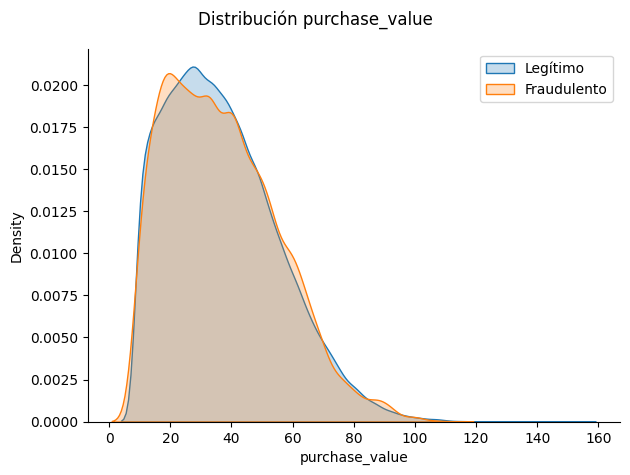

In [121]:

sns.kdeplot(data=numeric_df[numeric_df['class']==0], x='purchase_value', fill=True) # Distribución clase 0 con purchase_value
sns.kdeplot(data=numeric_df[numeric_df['class']==1], x='purchase_value', fill=True) # Distribución clase 1 con purchase_value
plt.legend(['Legítimo', 'Fraudulento'])
plt.suptitle('Distribución purchase_value')
sns.despine()
plt.tight_layout()
plt.show()

In [114]:
pd.concat([
    numeric_df[numeric_df['class']==0]['purchase_value'].describe(),
    numeric_df[numeric_df['class']==1]['purchase_value'].describe()
], axis=1, keys=['class = 0', 'class = 1']).T


,count,mean,std,min,25%,50%,75%,max
class = 0,136961.00,36.93,18.32,9.00,22.00,35.00,49.00,154.00
class = 1,14151.00,36.99,18.40,9.00,22.00,35.00,49.00,111.00


### 💾 **Observaciones**

Lo primero que salta a la luz es que ambas distribuciones son identicas o casi identicas compartiendo el mismo skewness a la derecha.

Tanto la clase 0 como la clase 1 tienen casi los mismos datos en las métricas centrales.
- El promedio, el std, el min los rangos cuartilicos son casi identicos.


La similitud tan grande en las distribuciones me lleva a pensar que los movimientos fraudulentos siguen la distribución de los datos legales para no levantar sospechas. Serán las distribuciones iguales ?

In [ ]:
valores_legitimos = numeric_df[numeric_df['class']==0]['purchase_value']
valores_fraudulentos = numeric_df[numeric_df['class']==1]['purchase_value']

Considerando los gráficos las distribuciones se ven lejos de ser normal pero aplicaremos igualmente un test estadístico para conocer la normalidad o no. Debido al tamaño de muestra utilizamos D'Agostino-Pearson

In [116]:
stat1, p1 = stats.normaltest(valores_fraudulentos)
stat2, p2 = stats.normaltest(valores_legitimos)
print(f"Fraude:    p={p1:.4f}")
print(f"No fraude: p={p2:.4f}")


Fraude:    p=0.0000
No fraude: p=0.0000


# Observación

Datos no normales por lo que necesitamos un test no paramétricos apra saber si las distribuciones son iguales o no.

In [118]:
stat, p = stats.mannwhitneyu(valores_fraudulentos, valores_legitimos)
print(f"stat={stat:.4f}, p={p:.4f}")

stat=970851302.5000, p=0.7180



Por lo tanto el monto no influye si es fraude o no.

In [119]:
from scipy import stats

stat, p = stats.ks_2samp(valores_fraudulentos, valores_legitimos)
print(f"stat={stat:.4f}, p={p:.4f}")

stat=0.0116, p=0.0646


Falla en rechazar la hipotesis nula de que las distribuciones son identicas. Por lo que lo más probable es que si lo sean como se ve arriba

# CONCLUSIÓN

Según lo observado tanto en los gráficos como en los diferentes tests estadisticos. El `purchase_value` no tiene evidencia estadisticamente relevante para ser un discriminante fuerte en si existira fraude o no.

### **2.1.3 Age**

In [130]:
pd.concat([
    numeric_df[numeric_df['class']==0]['age'].describe(),
    numeric_df[numeric_df['class']==1]['age'].describe()
], axis=1, keys=['class = 0', 'class = 1']).T


,count,mean,std,min,25%,50%,75%,max
class = 0,136961.00,33.12,8.62,18.00,27.00,33.00,39.00,76.00
class = 1,14151.00,33.32,8.57,18.00,27.00,33.00,39.00,68.00


En age para ambas clases igualmente el promedio, std y los rangos intercuartilicos son casi identicos.

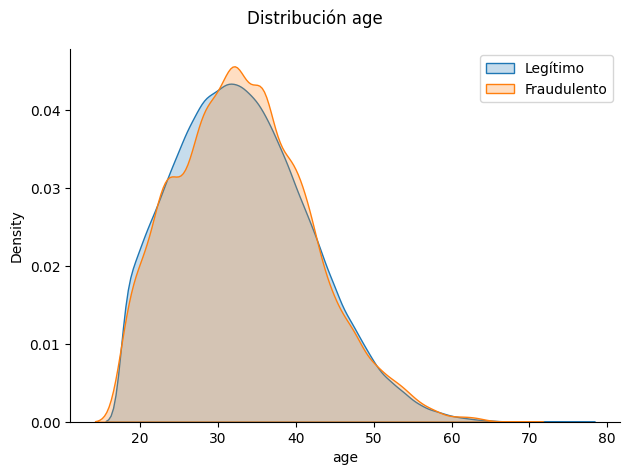

In [133]:
sns.kdeplot(data=numeric_df[numeric_df['class']==0], x='age', fill=True) # Distribución clase 0 con age
sns.kdeplot(data=numeric_df[numeric_df['class']==1], x='age', fill=True) # Distribución clase 1 con age
plt.legend(['Legítimo', 'Fraudulento'])
plt.suptitle('Distribución age')
sns.despine()
plt.tight_layout()
plt.show()

In [134]:
from scipy import stats

age_fraude    = df[df['class'] == 1]['age'].values
age_no_fraude = df[df['class'] == 0]['age'].values

stat_mw, p_mw = stats.mannwhitneyu(age_fraude, age_no_fraude)
stat_ks, p_ks = stats.ks_2samp(age_fraude, age_no_fraude)

print(f"Mann-Whitney: stat={stat_mw:.4f}, p={p_mw:.4f}")
print(f"KS test:      stat={stat_ks:.4f}, p={p_ks:.4f}")

Mann-Whitney: stat=983476583.5000, p=0.0035
KS test:      stat=0.0198, p=0.0001


In [135]:
print(f"Age media fraude:    {age_fraude.mean():.2f}")
print(f"Age media no fraude: {age_no_fraude.mean():.2f}")
print(f"Diferencia:          {abs(age_fraude.mean() - age_no_fraude.mean()):.2f} años")

Age media fraude:    33.32
Age media no fraude: 33.12
Diferencia:          0.20 años


Lo primero que salta a la vista que la distribución observada entre transaccciones fraudulentas y lefitimas parecen idénticas. Por otro lado los test estadisticos rechazan sus hipotesis nula, sugiriendo diferencias estadisticamente significantes entre estas clases.
Esta aparente contradicción viene dada en parte por el gran tamaño muestral, que detectan diferencias mínimas que en realidad no tienen relevancia. Por lo tanto considerando las metricas centrales se puede observar que `age` no posee una significancia práctica como feature dominante para detectar fraudes.

## **2.2. Variables Str**

In [145]:
df_str = df_merged.select_dtypes(include=['object', 'str'])
df_str.columns

Index(['signup_time', 'purchase_time', 'device_id', 'source', 'browser', 'sex',
       'country'],
      dtype='str')

<BarContainer object of 2 artists>

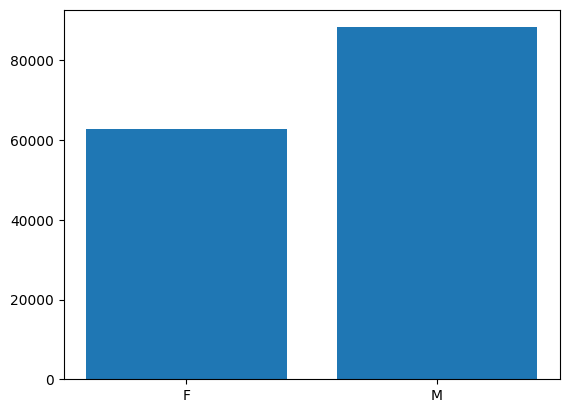

In [179]:
agrupado = df_merged.groupby('sex', as_index=False)['class'].size()
plt.bar(data=agrupado, x='sex', height='size')



In [170]:
agrupado

,class,size
0,0,136961
1,1,14151


In [167]:
agrupado

,sex,size
0,F,62819
1,M,88293
